Shape: (50487, 10)

Variation counts:
variation
Test       26961
Control    23526
Name: count, dtype: int64

Means by group:
            clnt_age  clnt_tenure_yr  num_accts            bal  calls_6_mnth  \
variation                                                                      
Control    47.498427       12.087860   2.259925  150151.900186      3.129176   
Test       47.163922       11.982901   2.249917  148962.605032      3.061941   

           logons_6_mnth  
variation                 
Control         6.166242  
Test            6.101851  

Medians by group:
           clnt_age  clnt_tenure_yr  num_accts       bal  calls_6_mnth  \
variation                                                                
Control        48.5            11.0        2.0  66031.45           3.0   
Test           47.5            11.0        2.0  65468.36           3.0   

           logons_6_mnth  
variation                 
Control              6.0  
Test                 6.0  

Age description by gr

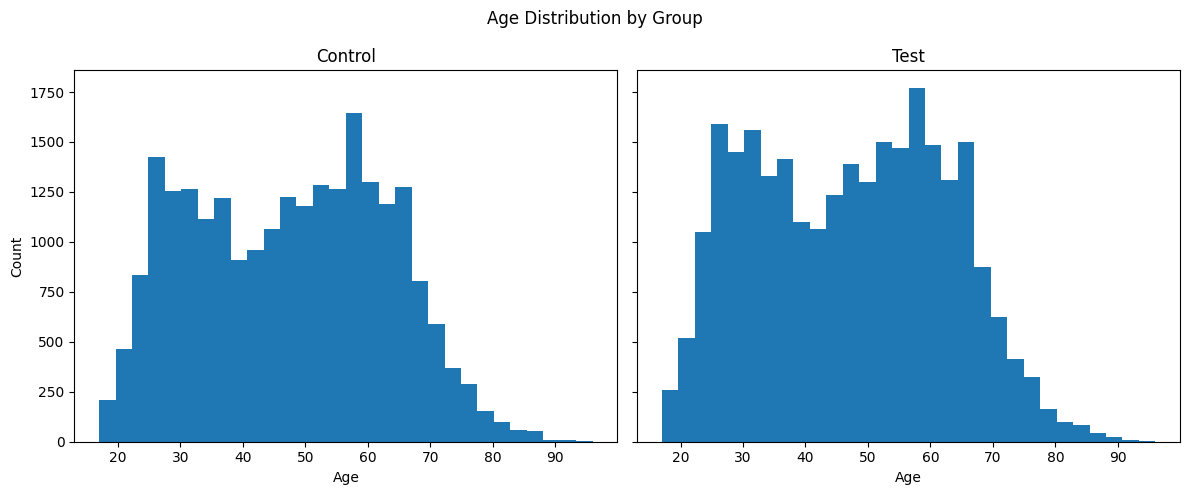

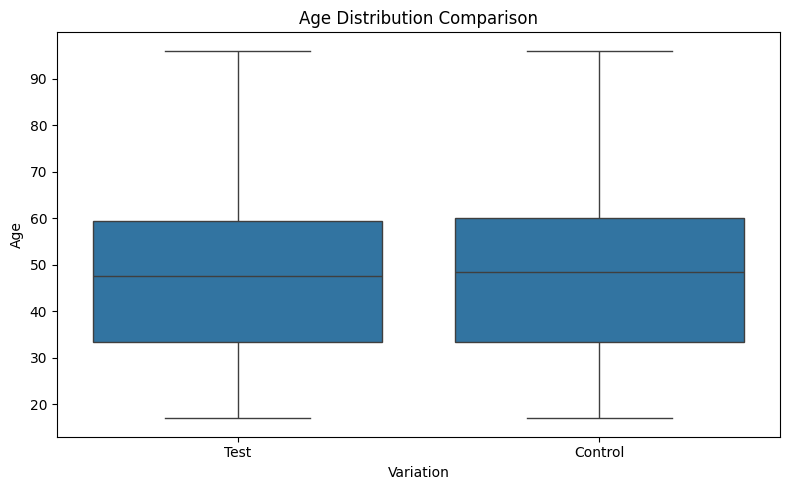

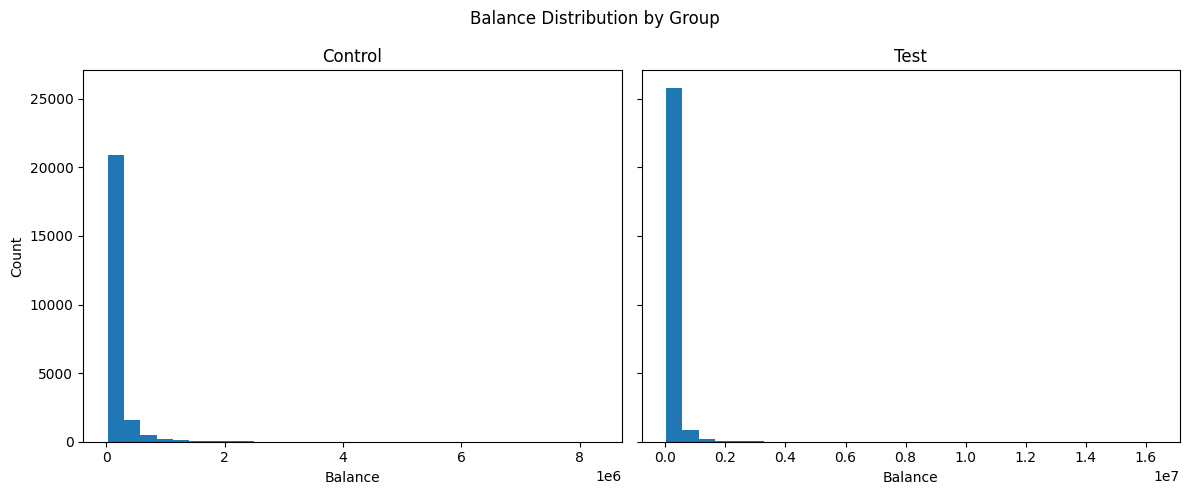

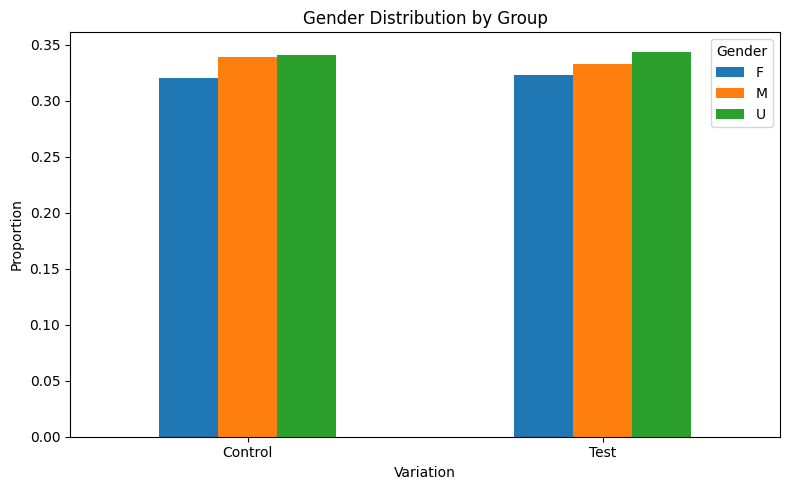

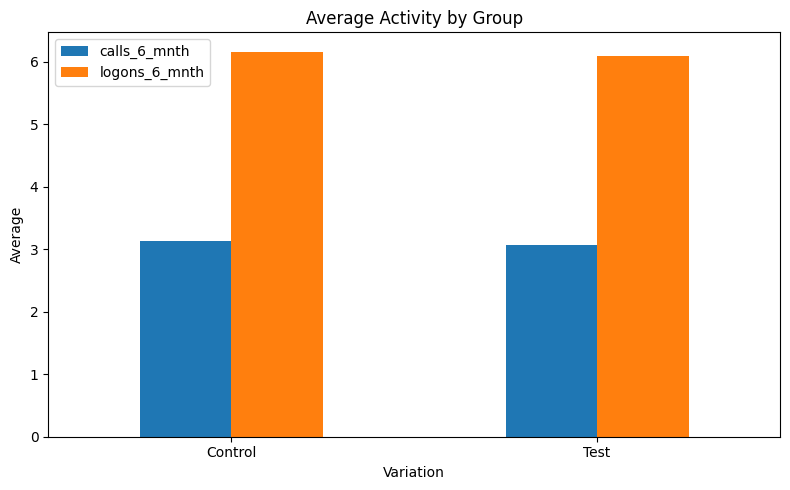


Age t-test
t-statistic: 2.416145610586789
p-value: 0.015689311849750105

Balance t-test
t-statistic: 0.44134212058143396
p-value: 0.6589672273121786

Gender chi-square test
chi2 statistic: 1.9039223438187003
p-value: 0.3859833010778912

Interpretation:
- Age differs significantly between Control and Test.
- No significant balance difference between Control and Test.
- No significant gender distribution difference between Control and Test.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# 1. Load the correct datasets
df_demo = pd.read_csv('../data/clean/df_final_demo.csv')
df_exp = pd.read_csv('../data/clean/df_final_experiment_clients_clean.csv')

# 2. Merge demographics with experiment group
df = df_demo.merge(df_exp, on='client_id', how='inner')

# 3. Keep only Control and Test
df = df[df['variation'].isin(['Control', 'Test'])].copy()

# 4. Quick check
print("Shape:", df.shape)
print("\nVariation counts:")
print(df['variation'].value_counts())

# 5. Summary statistics
print("\nMeans by group:")
print(df.groupby('variation')[[
    'clnt_age',
    'clnt_tenure_yr',
    'num_accts',
    'bal',
    'calls_6_mnth',
    'logons_6_mnth'
]].mean())

print("\nMedians by group:")
print(df.groupby('variation')[[
    'clnt_age',
    'clnt_tenure_yr',
    'num_accts',
    'bal',
    'calls_6_mnth',
    'logons_6_mnth'
]].median())

print("\nAge description by group:")
print(df.groupby('variation')['clnt_age'].describe())

print("\nGender distribution by group:")
print(pd.crosstab(df['variation'], df['gendr'], normalize='index'))

# 6. Visualizations

# Age distribution - fixed version (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, group in enumerate(['Control', 'Test']):
    subset = df[df['variation'] == group]
    axes[i].hist(subset['clnt_age'], bins=30)
    axes[i].set_title(group)
    axes[i].set_xlabel('Age')

axes[0].set_ylabel('Count')
plt.suptitle('Age Distribution by Group')
plt.tight_layout()
plt.show()

# Optional cleaner age comparison
plt.figure(figsize=(8, 5))
sns.boxplot(x='variation', y='clnt_age', data=df)
plt.title('Age Distribution Comparison')
plt.xlabel('Variation')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# Balance distribution - fixed version (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, group in enumerate(['Control', 'Test']):
    subset = df[df['variation'] == group]
    axes[i].hist(subset['bal'], bins=30)
    axes[i].set_title(group)
    axes[i].set_xlabel('Balance')

axes[0].set_ylabel('Count')
plt.suptitle('Balance Distribution by Group')
plt.tight_layout()
plt.show()

# Gender distribution
gender_dist = pd.crosstab(df['variation'], df['gendr'], normalize='index')
gender_dist.plot(kind='bar', figsize=(8, 5))
plt.title('Gender Distribution by Group')
plt.xlabel('Variation')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Activity comparison
activity = df.groupby('variation')[['calls_6_mnth', 'logons_6_mnth']].mean()
activity.plot(kind='bar', figsize=(8, 5))
plt.title('Average Activity by Group')
plt.xlabel('Variation')
plt.ylabel('Average')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Hypothesis testing

# Age: t-test
control_age = df[df['variation'] == 'Control']['clnt_age']
test_age = df[df['variation'] == 'Test']['clnt_age']
t_stat_age, p_value_age = ttest_ind(control_age, test_age, nan_policy='omit')

print("\nAge t-test")
print("t-statistic:", t_stat_age)
print("p-value:", p_value_age)

# Balance: t-test
control_bal = df[df['variation'] == 'Control']['bal']
test_bal = df[df['variation'] == 'Test']['bal']
t_stat_bal, p_value_bal = ttest_ind(control_bal, test_bal, nan_policy='omit')

print("\nBalance t-test")
print("t-statistic:", t_stat_bal)
print("p-value:", p_value_bal)

# Gender: chi-square test
gender_table = pd.crosstab(df['variation'], df['gendr'])
chi2, p_value_gender, dof, expected = chi2_contingency(gender_table)

print("\nGender chi-square test")
print("chi2 statistic:", chi2)
print("p-value:", p_value_gender)

# 8. Interpretation
alpha = 0.05

print("\nInterpretation:")
if p_value_age < alpha:
    print("- Age differs significantly between Control and Test.")
else:
    print("- No significant age difference between Control and Test.")

if p_value_bal < alpha:
    print("- Balance differs significantly between Control and Test.")
else:
    print("- No significant balance difference between Control and Test.")

if p_value_gender < alpha:
    print("- Gender distribution differs significantly between Control and Test.")
else:
    print("- No significant gender distribution difference between Control and Test.")